In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam # Import optimizer
from scikeras.wrappers import KerasClassifier # Wrapper untuk Keras di Scikit-learn

In [5]:
df = pd.read_csv('features_selected/Combined_selected_features.csv')

df

,TCD_Max,TCD_AUC,TCD_Mean,TVOC_Skew,TVOC_Decay,TVOC_Kurtosis,Label
0,4.653726,-48.900164,-0.155963,2.145402,0.181673,3.805084,butana
1,5.017747,66.527975,0.212078,1.899005,0.201204,2.544621,butana
2,6.416043,161.938268,0.514387,2.112537,0.130841,3.601863,butana
3,6.045575,-27.786546,-0.090326,2.126913,0.170684,3.671346,butana
4,6.633381,936.930212,2.969637,2.081987,0.149772,3.417740,butana
...,...,...,...,...,...,...,...
75,9.218774,50.246577,0.159674,2.115171,0.165337,3.673264,butana
76,3.632113,-98.794463,-0.313750,5.456874,0.663833,29.722503,spirtus
77,1.769671,-277.043813,-0.895336,5.442858,0.812571,29.091908,spirtus
78,7.703725,170.744481,0.541235,2.191213,0.168066,4.055420,butana


In [6]:
# Separate features (X) and target (y)
X = df.drop('Label', axis=1).values
y = df['Label'].values

# Encode the target variable (Label)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Normalisasi
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[0.38506345, 0.33694247, 0.33890323, 0.04471949, 0.0612923 ,
        0.02226172],
       [0.42322545, 0.41457803, 0.41674774, 0.        , 0.08484111,
        0.        ],
       [0.56981528, 0.47874983, 0.4806892 , 0.03875463, 0.        ,
        0.01867253],
       [0.53097746, 0.35114323, 0.35278606, 0.04136388, 0.04804108,
        0.0198997 ],
       [0.59259984, 1.        , 1.        , 0.03321014, 0.02282633,
        0.01542063],
       [0.38775598, 0.32780149, 0.32972296, 0.03836713, 0.05433586,
        0.01793439],
       [0.72637335, 0.        , 0.        , 0.01237104, 0.05541114,
        0.00471311],
       [0.22829084, 0.37268827, 0.3746801 , 0.65123194, 0.72792134,
        0.47600511],
       [0.37846354, 0.3998499 , 0.40171754, 0.01548756, 0.09911181,
        0.00633471],
       [0.55638751, 0.40370631, 0.40550603, 0.01078321, 0.07804691,
        0.00373893],
       [0.2798672 , 0.43226936, 0.4352996 , 0.71665486, 0.66012702,
        0.55975855],
       [0.59313352, 0

In [7]:
import tensorflow as tf

def create_model(lr, hidden_units,hidden_units1):
    model = Sequential()
    model.add(tf.keras.Input(shape=(X_scaled.shape[1],)))
    model.add(Dense(hidden_units, activation='relu'))
    model.add(Dense(hidden_units1, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'], )
    return model

# parameter
param_grid = {
    'model__lr': [0.001, 0.01],
    'model__hidden_units': [32],
    'model__hidden_units1': [16],
    'batch_size': [32],
    'epochs': [100, 120]
}

# keras clasifier
keras_model = KerasClassifier(model=create_model, verbose=0)

# cross validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Menggunakan 3 fold untuk contoh ini

# grid search
grid_search = GridSearchCV(
    estimator=keras_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1 #core cpu
)

# running
print("Memulai GridSearchCV...")
grid_search.fit(X_scaled, y_encoded)
print("GridSearchCV selesai.")

# coba print hasil
print("\n--- Hasil GridSearchCV ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best validation accuracy: {grid_search.best_score_:.4f}")

# best model
best_model = grid_search.best_estimator_

Memulai GridSearchCV...
GridSearchCV selesai.

--- Hasil GridSearchCV ---
Best parameters found: {'batch_size': 32, 'epochs': 100, 'model__hidden_units': 32, 'model__hidden_units1': 16, 'model__lr': 0.001}
Best validation accuracy: 1.0000


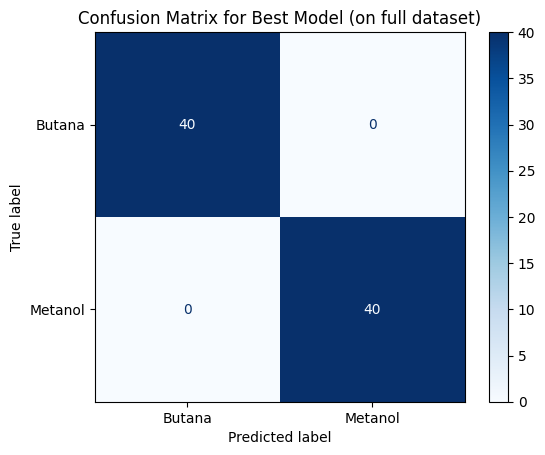


--- Classification Report (on full dataset) ---
              precision    recall  f1-score   support

      Butana       1.00      1.00      1.00        40
     Metanol       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np # Pastikan numpy diimpor

# Asumsi X_scaled dan y sudah ada dari langkah sebelumnya
# Asumsi best_model = grid_search.best_estimator_ sudah didefinisikan

# 1. Lakukan prediksi menggunakan model terbaik
# best_model.predict mengembalikan probabilitas, perlu diubah ke kelas biner (0 atau 1)
y_pred_prob = best_model.predict(X_scaled)

y_pred_prob

# Konversi probabilitas menjadi label kelas biner (0 atau 1)
# Untuk klasifikasi biner dengan sigmoid, ambang batas umum adalah 0.5
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Hitung Confusion Matrix
cm = confusion_matrix(y_encoded, y_pred)

# 3. Tampilkan Confusion Matrix
# Dapatkan nama kelas (jika tidak ada, gunakan 0 dan 1)
class_names = ['Butana', 'Metanol'] # Sesuaikan ini jika Anda memiliki nama kelas sebenarnya

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Best Model (on full dataset)')
plt.show()

# Opsional: Tampilkan metrik klasifikasi lainnya
from sklearn.metrics import classification_report
print("\n--- Classification Report (on full dataset) ---")
print(classification_report(y_encoded, y_pred, target_names=class_names))

Melatih model terakhir dengan hyperparameter terbaik (Epochs: 100, Batch Size: 32)...
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5125 - loss: 0.6809
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7250 - loss: 0.6609
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9625 - loss: 0.6420
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9750 - loss: 0.6229
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9875 - loss: 0.6045
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.5864
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.5679
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.5499
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.5314
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.5131
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - l

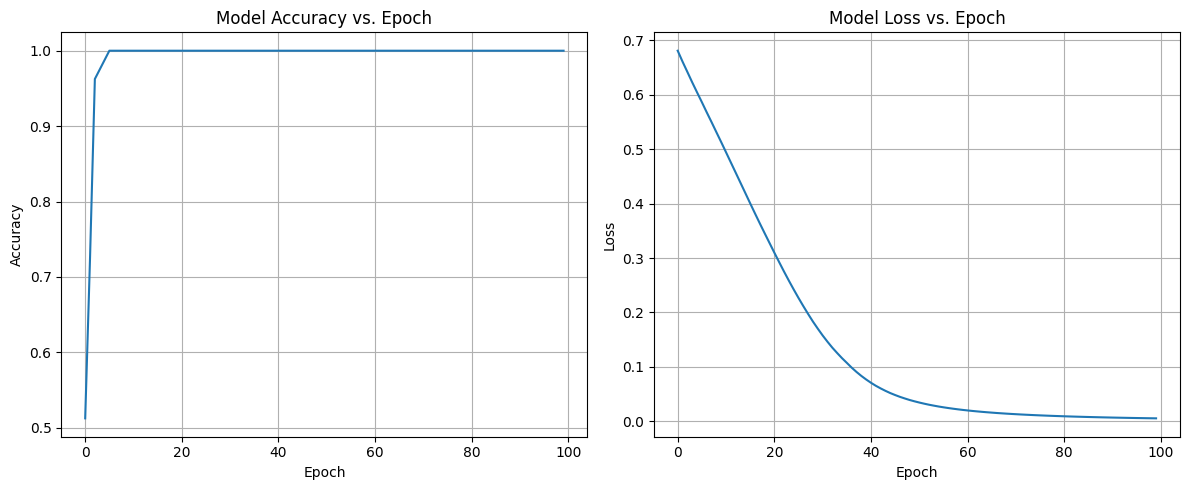

In [9]:
# Extract best parameters from grid_search
best_params = grid_search.best_params_
best_lr = best_params['model__lr']
best_hidden_units = best_params['model__hidden_units']
best_hidden_units1 = best_params['model__hidden_units1']
best_batch_size = best_params['batch_size']
best_epochs = best_params['epochs']

# Create a new model instance with the best parameters
# This ensures we get a fresh training history
final_model = create_model(
    lr=best_lr,
    hidden_units=best_hidden_units,
    hidden_units1=best_hidden_units1
)

# Train the final model on the full data, capturing the history
print(f"Melatih model terakhir dengan hyperparameter terbaik (Epochs: {best_epochs}, Batch Size: {best_batch_size})...")
history = final_model.fit(
    X_scaled, y_encoded,
    epochs=best_epochs,
    batch_size=best_batch_size,
    verbose=1 # Set verbose to 1 to see training progress and capture history
)
print("Pelatihan model terakhir selesai.")

# Plot Akurasi vs Epoch
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy vs. Epoch')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent overlap

# Plot Fungsi Loss vs Epoch
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'])
plt.title('Model Loss vs. Epoch')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent overlap

plt.show() # Display the plots